# **1. 오토인코더**
오토인코더(Autoencoder)는 입력 데이터를 효율적으로 압축하고 다시 복원하는 것을 목표로 하는 인공신경망 기반의 비지도 학습 모델입니다. 인코더(encoder)라는 신경망 구조를 통해 입력 데이터를 저차원(latent space)(실수)의 잠재 표현으로 변환하고, 디코더(decoder)를 통해 이를 다시 원래의 입력 데이터로 복원합니다. 학습은 원본 입력과 복원된 출력 간의 재구성 오류(reconstruction error)를 최소화하는 방식으로 이루어지며, 이를 통해 데이터의 핵심 특징을 추출하거나 노이즈 제거, 차원 축소 등에 활용됩니다. 오토인코더는 생성 모델의 기초가 되는 구조로서, 이후 변분 오토인코더(VAE)나 GAN과 같은 발전된 모델에도 큰 영향을 주었습니다.
![오토인코더](./images/오토인코더.png)

- Autoencoder는 입력을 정답으로 사용하는 신경망
- 예) 숫자 이미지 7을 입력하면 정답도 7 이미지
```
    입력 이미지 x > Encoder > Latent Vector z > Decoder > 복원 이미지 x_hat
```
> 원본 x와 복원된 결과 x_hat의 차이가 작아지도록 학습

### 비지도 학습

- 일반적인 이미지 분류
    - 강아지 이미지 > CNN > "강아지"
- Autoencoder
    - 강아지 이미지 > Encoder > Latent > Decoder > 강아지 이미지
    - 별도의 클래스 라벨이 필요하지 않기 때문에 전통적으로 비지도 학습 또는 자기지도적 표현 학습의 한 형태로 말함(입력이 곧 정답이므로)

### 1. Encoder
- Encoder는 입력을 더 작은 표현으로 바꿈
- 예) MNIST 이미지는 28 * 28 (784 픽셀) > Encoder > 784차원에서 128차원, 32차원으로 줄임
- 신경망이 복원에 필요한 특징을 스스로 학습

### 2. Decoder
- Decoder는 Encoder와 반대 방향으로 동작
- 예) latent z (32개 값) > Decoder > 784차원(28 * 28)
- Encoder가 남긴 제한된 정보만 보고 원본과 최대한 비슷한 데이터를 만드는 것

### 3. Reconstruction Loss
- Autoencoder는 원본과 복원본이 얼마나 다른지를 Loss로 계산
- 예) 원본 픽셀: 0.8, 복원된 픽셀: 0.6 > 오차 = (0.8 - 0.6)**2 = 0.04
- 모든 픽셀의 오차를 줄이도록 Encoder와 Decoder의 파라미터를 동시에 업데이트

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

torch.manual_seed(2026)

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

images, labels = next(iter(train_loader))
print("images:", images.shape)   # [B, 1, 28, 28]
print("labels:", labels.shape)

images: torch.Size([128, 1, 28, 28])
labels: torch.Size([128])


In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            # 1 * 28 * 28 (흑백이라 1)
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 28 -> 14 stride때문에 이미지 크기 줄음. 다만 특징 개수는 별개
            # 16 * 14 * 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 14 -> 7
            # 32 * 7 * 7
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            # conv2d는 사이즈를 키우고 stride로만 크기를 줄이기 때문(공간을 키우진 못함)에 아예 다른 convtranspose2d를 써야함
            nn.ConvTranspose2d( # 크기를 키움
                32, 16, kernel_size=3, stride=2, 
                padding=1, output_padding=1
            ),                                                     # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(
                16, 1, kernel_size=3, stride=2,
                padding=1, output_padding=1
            ),                                                     # 14 -> 28
            nn.Sigmoid() # 입력받은 값과 범위를 맞춰주기 위해
        )
        # Totensor()로 읽은 이미지 픽셀 값은 0~1 범위
        # Decoder의 마지막 출력도 0~1 범위가 되도록 설정

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat


model = ConvAutoencoder().to(DEVICE)
model

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

In [5]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

def train_autoencoder(model, loader, criterion, optimizer, device, epochs=5):
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for x, _ in loader:
            x = x.to(device)

            _, x_hat = model(x)
            loss = criterion(x_hat, x) # 지도학습의 label 역할

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.6f}")

    return history

history = train_autoencoder(
    model, train_loader, criterion, optimizer, DEVICE, epochs=5
)

Epoch 01/5 | Loss: 0.030256
Epoch 02/5 | Loss: 0.001882
Epoch 03/5 | Loss: 0.001151
Epoch 04/5 | Loss: 0.000870
Epoch 05/5 | Loss: 0.000722


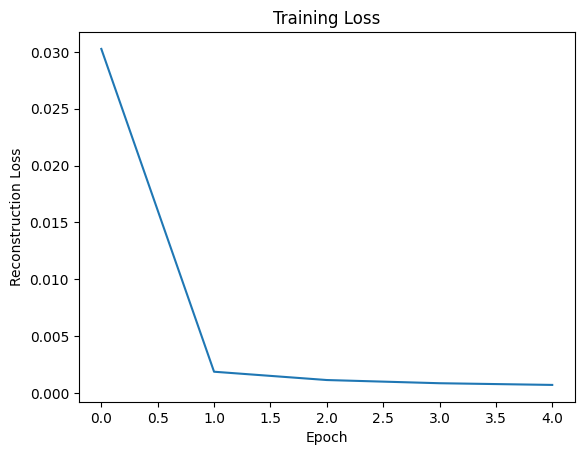

In [6]:
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Training Loss")
plt.show()

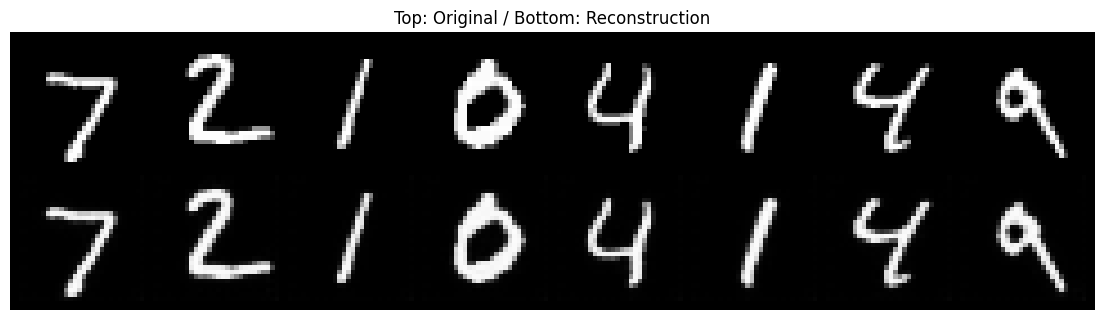

In [7]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    x, _ = next(iter(loader)) # 정답은 필요없어 안가져옴
    x = x[:n].to(device)

    _, x_hat = model(x)

    comparison = torch.cat([x.cpu(), x_hat.cpu()], dim=0)
    grid = make_grid(comparison, nrow=n, padding=2)

    plt.figure(figsize=(14, 4))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Top: Original / Bottom: Reconstruction")
    plt.show()

show_reconstructions(model, test_loader, DEVICE)

# 위의 행이 원본
# 아래 행이 autoencoder로 복원한 행

autoencoder
생성형
원본과 다른 이미지를 생성하기 위해 예전에 사용했음

### 4. Latent Representation

- Encoder만 따로 사용할 수도 있음
    - z = model.encoder(x)
    - z는 이미지 자체가 아니라 이미지의 압축된 특징 표현

In [8]:
x, y = next(iter(test_loader))
x = x[:8].to(DEVICE)

with torch.no_grad():
    z = model.encoder(x)

print("입력 shape :", x.shape)
print("latent shape:", z.shape)
print("한 이미지의 원래 값 개수 :", 1 * 28 * 28)
print("한 이미지의 latent 값 개수:", z[0].numel())

입력 shape : torch.Size([8, 1, 28, 28])
latent shape: torch.Size([8, 32, 7, 7])
한 이미지의 원래 값 개수 : 784
한 이미지의 latent 값 개수: 1568


> 위 구조의 latent가 반드시 원본보다 훨씬 작은 것은 아님

- Autoencoder에서 중요한 것은 단순히 숫자 개수만 줄이는 것이 아님
- 현대적인 autoencoder에서는 공간 해상도를 줄이고, 채널을 늘려 유용한 표현 공간으로 변환하기도 함

# **2. Denoising Autoencoder**

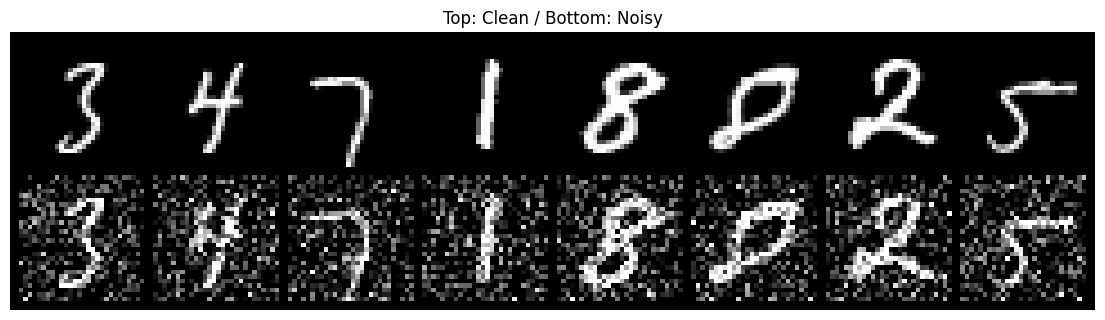

In [ ]:
def add_noise(x, noise_factor=0.35):
    noisy = x + noise_factor * torch.randn_like(x) # 랜덤 값으로 노이즈 부여
    return torch.clamp(noisy, 0.0, 1.0) # 0~1로 노이즈 자름

x, _ = next(iter(train_loader))
noisy_x = add_noise(x[:8])

grid = make_grid(torch.cat([x[:8], noisy_x], dim=0), nrow=8)

plt.figure(figsize=(14, 4))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Top: Clean / Bottom: Noisy")
plt.show()

In [ ]:
denoising_model = ConvAutoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.AdamW(denoising_model.parameters(), lr=1e-3)

def train_denoising_autoencoder(model, loader, criterion, optimizer, device, epochs=5):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for clean_x, _ in loader:
            clean_x = clean_x.to(device)
            noisy_x = add_noise(clean_x)

            _, restored_x = model(noisy_x) # 노이즈 있는 이미지를 입력
            loss = criterion(restored_x, clean_x) # 비교는 깨끗한 이미지와
            # 학습은 깨끗한 이미지로 됨

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * clean_x.size(0)

        epoch_loss = running_loss / len(loader.dataset)
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.6f}")

train_denoising_autoencoder(
    denoising_model, train_loader, criterion, optimizer, DEVICE, epochs=5
)

Epoch 01/5 | Loss: 0.041622
Epoch 02/5 | Loss: 0.008156
Epoch 03/5 | Loss: 0.007679
Epoch 04/5 | Loss: 0.007475
Epoch 05/5 | Loss: 0.007326


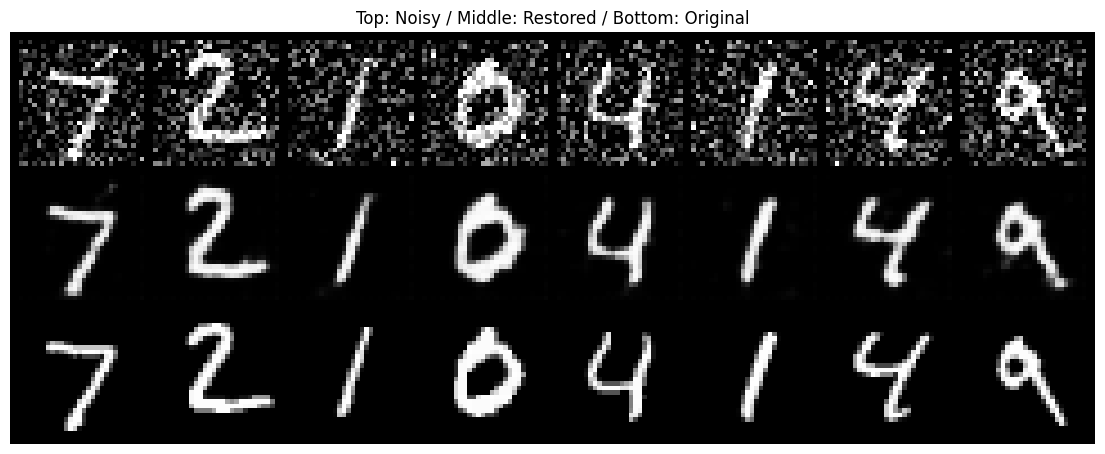

In [11]:
@torch.no_grad()
def show_denoising_result(model, loader, device, n=8):
    model.eval()

    clean_x, _ = next(iter(loader))
    clean_x = clean_x[:n].to(device)
    noisy_x = add_noise(clean_x)

    _, restored_x = model(noisy_x)

    result = torch.cat([
        noisy_x.cpu(),
        restored_x.cpu(),
        clean_x.cpu()
    ], dim=0)

    grid = make_grid(result, nrow=n, padding=2)

    plt.figure(figsize=(14, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Top: Noisy / Middle: Restored / Bottom: Original")
    plt.show()

show_denoising_result(denoising_model, test_loader, DEVICE)

autoencoder 잡음이 있는 영상에서 이를 제거할 때도 사용됨

latent값을 내가 임의로 decoder에 전달하면 이게 이미지로 복원이 될까?
-> 안됨.
압축도 학습이 되어서 하기 때문에 사람이 제대로 못넣음

-> 우리가 원하는 걸 만들어낼 수는 없음

# **3. Sparse Autoencoder**
- Autoencoder는 latent의 많은 뉴런을 자유롭게 사용할 수 있음
- Sparse Autoencoder는 뉴런에 제약을 추가하여 적은 수의 뉴런만 강하게 사용하도록 유도
    - 일반: [0.7, 0.5, 0.9, 0.4, 0.6, 0.8]
    - Sparse Autoencoder: [0.0, 0.0, 1.3, 0.0, 0.9, 0.0]

> latent에 어떤 제약을 주느냐에 따라 표현의 성질이 달라짐

### Autoencoder를 이용한 이상 탐지
- 정상 데이터만 충분히 학습
    - 정상 데이터 > 잘 복원됨 > Reconstruction Error 작음
    - 이상 데이터 > 잘 복원하지 못함 > Reconstruction Error 큼

> 단, 실제 시스템에서는 Autoencoder가 이상 데이터까지 너무 잘 복원하는 경우도 있으므로 재구성 오차만으로 모든 이상 탐지 문제가 해결되는 것은 아님. 데이터와 문제에 따라 여러 방법을 고려해야 함.

### Autoencoder의 핵심 한계
- 생성형 AI 관점에서 일반 Autoencoder는 학습 이미지에 대해 x > Encoder > z > Decoder > x_hat 를 잘할 수 있음
- 만약 새 이미지를 생성하려면 시작점 z가 필요함
    - ??? > z > Decoder > 새로운 이미지

- 일반 Autoencoder의 latent space가 우리가 원하는 규칙적인 확률분포가 되도록 학습되지 않음
- latent 공간의 어떤 위치에는 학습된 데이터가 존재하지만 그 사이에는 Decoder가 제대로 학습하지 않은 영역이 생길 수 있음
- 랜덤한 z를 Decoder에 넣는다고 해서 자연스러운 샘플이 나오지 않음

> 복원을 잘하는 것과 새로운 데이터를 잘 생성하는 것은 같은 문제가 아님

# **4. VAE(Variational Autoencoder)**

```
사진 > Encoder > 작은 특징값 z > Decoder > 원래 사진과 비슷하게 복원
예) 손글씨 숫자 3을 넣었더니 Encoder가 z = [2.1, -0.7]
    다른 손글씨 숫자 3을 넣었더니 Encoder가 z = [2.8, -1.7]
    그런데 새로운 숫자 이미지를 만들고 싶음. z = [0.2, 4.7]을 Decoder에 넣음
```
- Latent space를 아무 데서나 뽑아도 어느 정도 의미 있는 결과가 나오도록 좀 더 규칙적으로 만듬

### VAE의 아이디어
- 일반 Autoencoder
    - 이미지 하나를 정확한 좌표 하나로 바꿈
```
    사진1 > z =  [2.0, 3.0] = 지도에 비유하면 정확한 주소 한 곳
```
- VAE
    - 정확히 점을 나타내는 것이 아니라 대략 근처를 표현
    - 지도에 비유하면 주소 하나가 아니라 동네 하나를 정하는 것
    - 평균(μ) = 동네의 중심은 어디인가?, 표준편차(σ) = 그 동네가 얼마나 넓게 퍼져 있나?
```
μ, σ > 범위 결정 > 그 안에서 z 하나 선택 > Decoder

μ: 중심
σ: 퍼짐 정도
z: 그 범위에서 실제로 뽑은 한 점
```

### 범위를 만드는 이유
- 학습된 점들 사이의 위치는 Decoder가 제대로 배운 적이 없는 곳일 수 있음 > 임의의 z를 뽑았을 때 이상한 이미지가 나올 수 있음
- VAE는 각 데이터를 점 하나가 아니라 주변 범위까지 포함해서 표현하고, 이 범위들이 너무 제멋대로 흩어지지 않도록 제한

> VAE의 핵심은 단순히 랜덤하게 만드는 것이 아니라, 랜덤 샘플링이 가능하도록 latent space에 규칙을 주는 것

생성형 AI에 있어 기본이 되므로 잘 기억하기

```
예)
Encoder가 어떤 이미지에 대해 μ=5, σ=0.5 정보를 만듬
- 중심은 5 근처이고, 대부분 5 주변에 0.5(좁은 범위)에서 z를 뽑음

Encoder가 어떤 이미지에 대해 μ=5, σ=3 정보를 만듬
- 같은 5가 중심이지만 훨씬 넓은 범위에서 값을 뽑을 수 있음
```

```
mu, logvar = encoder(x) # var = σ², logvar = log(σ²) logvar인 이유는 분산에 음수값이 들어가지 않게 하기 위해
# logvar > σ = torch.exp(0.5 * logvar)
x > Encoder > μ, σ > z 하나 뽑기 > Decoder > x_hat
```

In [ ]:
mu = torch.tensor([[1.0, 2.0]])
logvar = torch.tensor([[0.0, 0.0]])

std = torch.exp(0.5 * logvar)
eps = torch.randn_like(std) # 랜덤한 작은 값
z = mu + eps * std

print("mu     :", mu)
print("logvar :", logvar)
print("std    :", std)
print("epsilon:", eps)
print("z      :", z)

mu     : tensor([[1., 2.]])
logvar : tensor([[0., 0.]])
std    : tensor([[1., 1.]])
epsilon: tensor([[-1.4390, -0.2937]])
z      : tensor([[-0.4390,  1.7063]])


### z를 뽑는 방법

1. 먼저 랜덤 숫자를 뽑음
```
eps = torch.randn_like(std) : 평균 0, 표준편차 1인 정규분포에서 뽑은 랜덤 값
```
2. 랜덤 값을 원하는 위치와 크기로 옮김
```
z = mu(5) + eps(0.3) * std(2)
z = 5.6
```
> 랜덤성을 eps로 만들고 z = mu + eps * std로 계산하면, 랜덤 샘플링을 하면서 mu와 std를 만드는 Encoder를 학습할 수 있음

### VAE Loss
1. Latent 공간을 약속한 기준 분포인 표준정규분포에서 멀리 떨어지지 않도록 정리(KL Divergence)
```
KL Loss
Encoder가 만든 분포가 우리가 기준으로 삼은 N(0,1)과 너무 멀리 떨어지지 않도록 함

VAE Loss = 복원을 잘 못한 벌점 + latent 공간이 너무 흐트러진 벌점
(Reconstruction Loss + KL Loss)
```

$$
L_{VAE}=L_{reconstruction}+L_{KL}
$$

```
kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
```

In [ ]:
import torch.nn.functional as F

LATENT_DIM = 2

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        self.flatten_dim = 64 * 7 * 7

        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim) # 인코더의 마지막 출력값을 latent_dim으로 줄이기 위해 fc layer를 사용
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.flatten_dim)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x) # x.shape = [B, 1, 28, 28] -> h.shape = [B, 64, 7, 7]
        # 예) [128, 64, 7, 7] -> [128, 64*7*7]
        h = h.view(x.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 64, 7, 7) # -1은 batch size

        x_hat = self.decoder(h)
        return x_hat

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        return x_hat, mu, logvar


vae = ConvVAE(latent_dim=LATENT_DIM).to( DEVICE)
print(vae)

ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=3136, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=2, bias=True)
  (fc_decode): Linear(in_features=2, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)


In [ ]:
# 두 가지 loss를 합쳐서 최종 loss로 사용
# 전체적인 이미지 오차
# 얼마나 퍼졌는지

def vae_loss_function(x_hat, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(
        x_hat, x,
        reduction="sum"
    )

    # 범위를 벗어난 것에 대한 오차
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    batch_size = x.size(0)

    total_loss = (recon_loss + kl_loss) / batch_size
    recon_loss = recon_loss / batch_size
    kl_loss = kl_loss / batch_size

    return total_loss, recon_loss, kl_loss

In [17]:
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

def train_vae(model, loader, optimizer, device, epochs=10):
    history = {
        "total": [],
        "recon": [],
        "kl": []
    }

    for epoch in range(1, epochs + 1):
        model.train()

        total_sum = 0.0
        recon_sum = 0.0
        kl_sum = 0.0

        for x, _ in loader:
            x = x.to(device)

            optimizer.zero_grad()

            x_hat, mu, logvar = model(x)

            loss, recon_loss, kl_loss = vae_loss_function(
                x_hat, x, mu, logvar
            )

            loss.backward()
            optimizer.step()

            total_sum += loss.item()
            recon_sum += recon_loss.item()
            kl_sum += kl_loss.item()

        n_batches = len(loader)

        avg_total = total_sum / n_batches
        avg_recon = recon_sum / n_batches
        avg_kl = kl_sum / n_batches

        history["total"].append(avg_total)
        history["recon"].append(avg_recon)
        history["kl"].append(avg_kl)

        print(
            f"Epoch [{epoch:02d}/{epochs}] "
            f"Total: {avg_total:.4f} | "
            f"Recon: {avg_recon:.4f} | "
            f"KL: {avg_kl:.4f}"
        )

    return history


vae_history = train_vae(
    vae,
    train_loader,
    optimizer,
    DEVICE,
    epochs=10
)

Epoch [01/10] Total: 200.7453 | Recon: 194.8352 | KL: 5.9101
Epoch [02/10] Total: 172.5610 | Recon: 167.7199 | KL: 4.8411
Epoch [03/10] Total: 167.2174 | Recon: 162.2874 | KL: 4.9300
Epoch [04/10] Total: 164.0457 | Recon: 158.9974 | KL: 5.0483
Epoch [05/10] Total: 162.0013 | Recon: 156.8674 | KL: 5.1339
Epoch [06/10] Total: 160.6255 | Recon: 155.4392 | KL: 5.1863
Epoch [07/10] Total: 159.5960 | Recon: 154.3420 | KL: 5.2539
Epoch [08/10] Total: 158.7298 | Recon: 153.4216 | KL: 5.3082
Epoch [09/10] Total: 157.9928 | Recon: 152.6275 | KL: 5.3653
Epoch [10/10] Total: 157.4881 | Recon: 152.0740 | KL: 5.4141


- Total Loss만 보면 VAE가 복원 때문에 좋아지는지, latent 때문에 변하는지 구분하기 어려움
- Recon이 감소되면 Decoder가 입력 이미지를 점점 잘 복원하고 있다는 뜻
- KL이 감소되면 Encoder가 만든 latent distribution을 N(0,1)에 가깝게 정리하는 과정이 일어나고 있다는 뜻
- KL값이 무조건 작을수록 좋다고 단순 해석을 하면 안됨
    - KL이 지나치게 빠르게 0이 되면 Decoder가 latent 정보를 거의 사용하지 않는 현상이 일어남

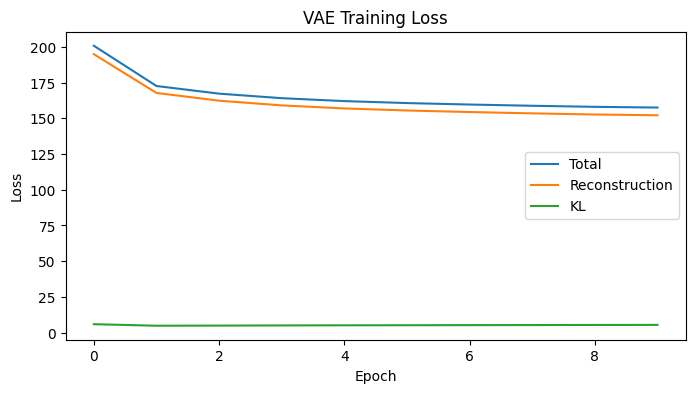

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(vae_history["total"], label="Total")
plt.plot(vae_history["recon"], label="Reconstruction")
plt.plot(vae_history["kl"], label="KL")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss")
plt.legend()
plt.show()

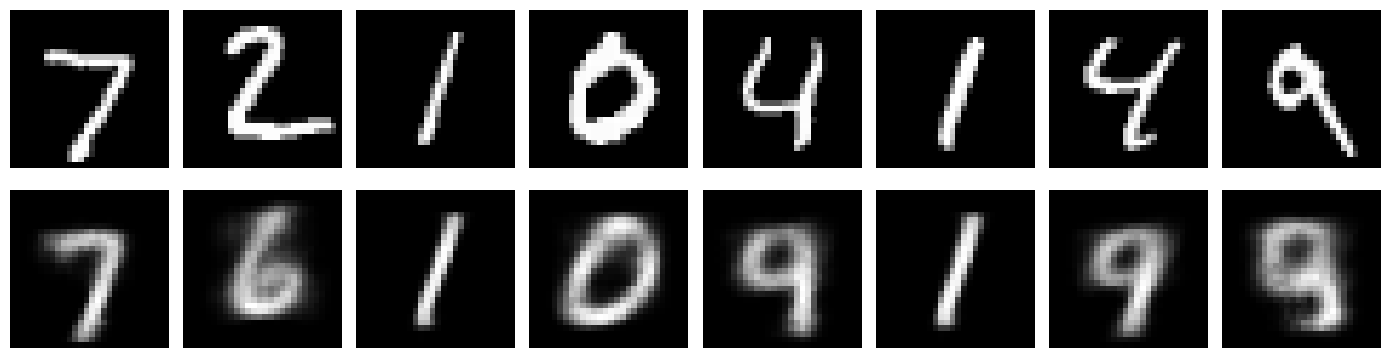

In [20]:
@torch.no_grad()
def show_vae_reconstructions(model, loader, device, n=8):
    model.eval()

    x, _ = next(iter(loader))
    x = x[:n].to(device)

    x_hat, _, _ = model(x)

    fig, axes = plt.subplots(2, n, figsize=(14, 4))

    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap="gray")
        axes[0, i].axis("off")

        axes[1, i].imshow(x_hat[i, 0].cpu(), cmap="gray")
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Recon")

    plt.tight_layout()
    plt.show()


show_vae_reconstructions(vae, test_loader, DEVICE)

- Autoencoder와 달리 VAE는 중간에서 z를 확률적으로 샘플링하므로 복원 결과가 부드럽거나 흐릿하게 보일 수 있음
- 전통적인 VAE에서 자주 보이는 blur는 픽셀 단위와 단순한 구조 등 여러 요인의 영향을 받음

### 2026년 관점에서 VAE의 중요성

- 현재 고품질 이미지 생성의 중심은 단순 VAE 하나만 사용하는 방식이 아니라 Diffusion, Transformer, Flowe 계열 등과 결합된 구조로 발견
- 대표적으로 latent 기반 생성 모델에서는 고해상도 픽셀 공간을 그대로 다루는 대신, 먼저 이미지를 작은 latent representation으로 압축한 뒤 그 공간에서 생성 과정을 수행

```
Image > VAE Encoder > Latent Representation > Diffusion / Transformer 등 생성 모델 > Generated Latent > VAE Decoder > Generated Image
```

> VAE는 확률적인 latent representation을 학습하는 기본 도구이며, 현대 생성 모델의 latent-space 사고 방식을 이해하는 중요한 기반